In [ ]:
!pip install jaxopt

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxopt import LBFGS

In [ ]:
seed = 0
key = jax.random.key(seed)
jax.config.update("jax_enable_x64", True)

In [ ]:
def project(v,n):
  return v-jnp.dot(v,n)/jnp.dot(n,n)*n

def log_r(x, xi, nx, y, xi_prime, ny, beta):
  phi = 0.5*jnp.log(jnp.dot(nx,nx)/jnp.dot(ny,ny))
  gaussian_term = (jnp.linalg.norm(x) + jnp.linalg.norm(y))*(jnp.linalg.norm(x)-jnp.linalg.norm(y))
  proposal_term = (jnp.linalg.norm(xi)+jnp.linalg.norm(xi_prime))*(jnp.linalg.norm(xi)-jnp.linalg.norm(xi_prime))
  return phi + 0.5 * gaussian_term + (1 / (2 * beta**2)) * proposal_term

def compute_reverse(x, y, n, beta):
    return project(x-jnp.sqrt(1-beta**2)*y, n)

In [ ]:
def manifold(d,z=0):

  x_0 = jnp.float64(0)
  tt = 1
  dt = tt/d
  dW = jnp.sqrt(dt)
  t0=dt

  def diffusion():
    return 1.0

  def drift(x):
    return 0.0

  def pathstep(x_i, rand_var):
    x_i += drift(x_i)*dt + diffusion()*dW*rand_var
    return x_i, x_i

  def F_full(x):
    end, sample_path = jax.lax.scan(pathstep, x_0 ,x)
    return end, sample_path

  def F(x):
    _, out = F_full(x)
    peak = jnp.max(out)
    return peak - z

  def x0():
    def h(x):
      return 0.5*jnp.dot(x,x)
    c = 1e6
    def pen(x):
      val = F(x)
      return c*val**2
    def J(x):
      return h(x) + pen(x)
    init = jax.random.normal(shape=(d,),key=jax.random.key(seed+1))
    solver = LBFGS(fun=J,maxiter=100,tol=1e-3)
    solns = solver.run(init)
    return solns.params

  def nx0():
    return jax.grad(F,allow_int=True)(x0())

  def manifoldproject(x, n, tol=1e-3, maxiter=100):
    def f(val):
      a,i = val
      ff = lambda a: F(x + a * n)
      fff = ff(a)
      dff = jax.grad(ff)(a)
      return (a-fff/dff, i+1)
    def cond(val):
      a,i = val
      return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
    a,_ = jax.lax.while_loop(cond, f, (0.0,0))
    success = lambda a: jnp.abs(F(x + a * n))<tol
    return jnp.where(success(a), x + a * n, x)

  return F, x0, nx0, manifoldproject, F_full

In [ ]:
def PCN(beta=0.5, d=jnp.int32(1e4), burnin=1000, N=0, z=0):
    F, x0, nx0, manifoldproject, F_full = manifold(d,z=z)
    keylist = jax.random.split(key, N+burnin)

    @jax.jit
    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, nx, y, xi_prime, ny, beta)
        acc = jnp.logical_and(F(y)<1e-3,(jnp.log(jax.random.uniform(current_key)) < R))
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin,acc,0)
        it += 1
        return (x, nx, accs, it), (R, x)

    (eta, _, accs, _), (Rs, xs) = jax.lax.scan(sampleStep, (x0(), nx0(), 0, 0), keylist)
    _, path = F_full(eta)
    stats = [np.mean(Rs[burnin:]), accs/(N+burnin)]
    sample_path = np.array(path)
    plt.xlabel('timesteps')
    plt.ylabel('B_t')
    plt.title('Brownian motion sample paths')
    plt.plot(range(len(sample_path)),sample_path)
    print('Accepted:', accs, 'out of', N+burnin)
    print('Error:', np.max(sample_path) - z)

    return np.array(xs)

In [ ]:
n = 1000
b = 1000

Accepted: 1913 out of 2000
Error: 4.440892098500626e-16
Accepted: 1626 out of 1700
Error: -5.329070518200751e-15
Accepted: 1350 out of 1400
Error: -6.106226635438361e-14
(2000, 10000)


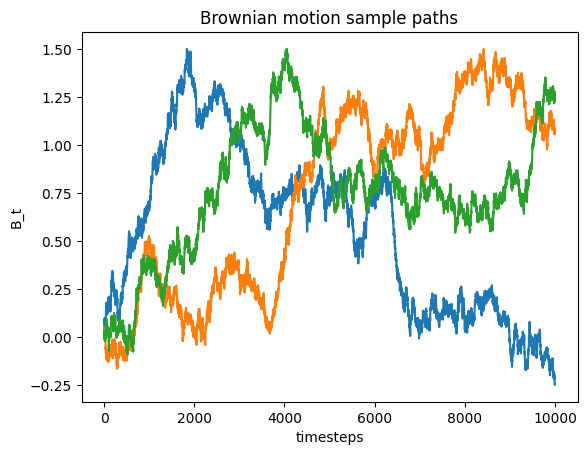

In [ ]:
xs = PCN(z=1.5,N=n,burnin=b)
PCN(z=1.5,N=n-300,burnin=b)
PCN(z=1.5,N=n-600,burnin=b)
print(xs.shape)

In [ ]:
xs_samples = xs[b:,:]
print(xs_samples.shape)

_,_,_,_,F_full = manifold(10000,z=1.5)

def rng(x):
  _, bm_path = F_full(x)
  return np.max(bm_path)-np.min(bm_path)

ranges = []
for i in range(n):
  ranges.append(rng(xs_samples[i,:]))

(1000, 10000)


Text(0, 0.5, 'Frequency')

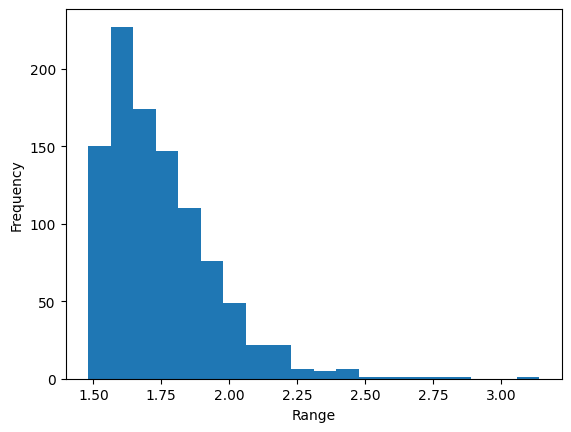

In [ ]:
plt.hist(ranges,bins=20)
plt.xlabel('Range')
plt.ylabel('Frequency')